# <a id='toc1_'></a>[Topic 19 - Lag Design](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Topic 19 - Lag Design](#toc1_)    
  - [Lag vs gain (19-4)](#toc1_1_)    
  - [Lag Example on 19-5](#toc1_2_)    
    - [Add Lag](#toc1_2_1_)    
- [Bode design 3 (19-16)](#toc2_)    
- [Class example (19-19)](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [4]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_1_'></a>[Lag vs gain (19-4)](#toc0_)

In [5]:
G = 50*ct.tf([1],np.convolve((1,4),np.convolve((1,2),(1,3))))
K=10
selected_zero=2/3;
Gc_lag = ct.tf([1, selected_zero],[1, selected_zero/K])

w = np.sort(np.append(np.logspace(-2,2,500),1))
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[GGcm,GGcp,GGcw] = ct.frequency_response(Gc_lag*G,omega=w)
[Lm,Lp,Lw] = ct.frequency_response(K*G,omega=w)

wc_lag, idx = cm.find_wc(w,GGcm)
wc_gain, idx = cm.find_wc(w,Lm)

print(f"{wc_lag = :4.2f} rad/sec")

wc_lag = 2.27 rad/sec


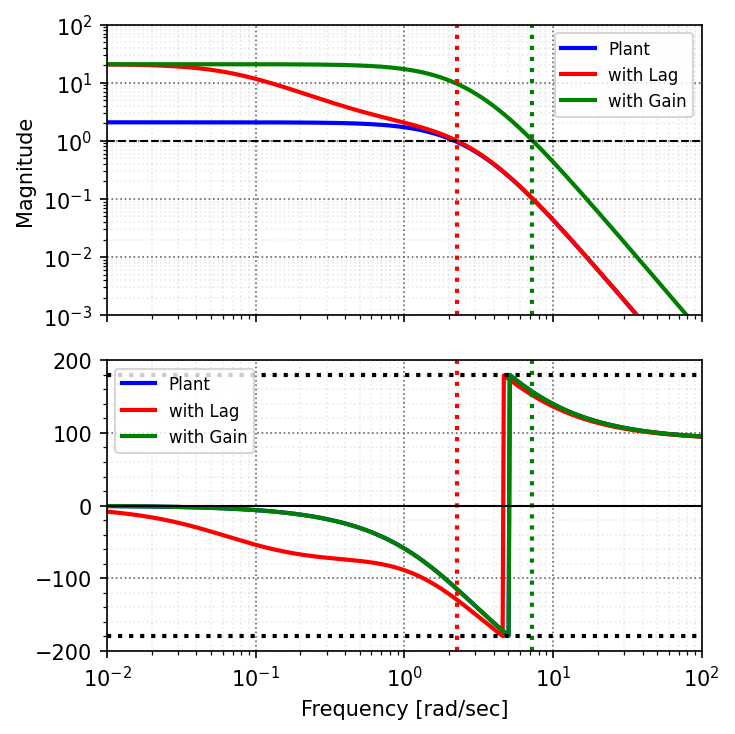

In [6]:

fig, ax = plt.subplots(2,1,figsize=(5,5),dpi=150,sharex=True)
ax[0].loglog(Gw,Gm,'b-',label='Plant')
ax[0].loglog(GGcw,GGcm,'r-',label='with Lag')
ax[0].loglog(Lw,Lm,'g-',label='with Gain')
ax[0].axvline(x=wc_lag,c='r',ls=':')
ax[0].axvline(x=wc_gain,c='g',ls=':')

ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'b-',label='Plant')
ax[1].semilogx(GGcw,cm.r2d*cm.pshift(GGcp),'r-',label='with Lag')
ax[1].semilogx(Lw,cm.r2d*cm.pshift(Lp),'g-',label='with Gain')
ax[1].axvline(x=wc_lag,c='r',ls=':')
ax[1].axvline(x=wc_gain,c='g',ls=':')
ax[1].axhline(y=-180,c='k',ls=':')
ax[1].axhline(y=180,c='k',ls=':')

ax[0].legend(fontsize=8)
ax[1].legend(fontsize=8)
ax[0].set_ylim([1e-3,100])
ax[1].set_ylim([-200,200])
#ax.set_xlim([1e-3,1e1])
ax[0].set_ylabel("Magnitude")
ax[1].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L17_4.pdf',dpi=600)
plt.show()


## <a id='toc1_2_'></a>[Lag Example on 19-5](#toc0_)

In [7]:
G = ct.tf(3,np.convolve([1, 1],np.convolve([1, 1],[1/2, 1])))
Gclag = cm.lag_design(gain_inc = 10, gamma = 10, wc = 1)
L = G*Gclag
cm.write_tf_latex(G, filename="./figs/G19_5.tex", label="G(s)",show=True,factor=True,sigfigs=0,inline=True)
cm.write_tf_latex(Gclag, filename="./figs/Gc19_5.tex", label="G_{c_{lag}}(s)",show=True,inline=True,sigfigs=2)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
gain1 = 1.5
gain2 = 2
w = np.logspace(-2,np.log10(10),300)

Gcl1 = ct.feedback(gain1*G)
Gcl2 = ct.feedback(gain2*G)
Gcl = ct.feedback(L)

scl = np.roots(Gcl.den[0][0])
scl1 = np.roots(Gcl1.den[0][0])
scl2 = np.roots(Gcl2.den[0][0])

Tf = 100
y_lag1,t_lag1 = cmat.step(Gcl1,Tf)
y_lag2,t_lag2 = cmat.step(Gcl2,Tf)
y_lag,t_lag = cmat.step(Gcl,Tf)

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[G1m,G1p,G1w] = ct.frequency_response(gain1*G,omega=w)
[G2m,G2p,G2w] = ct.frequency_response(gain2*G,omega=w)
[Lm,Lp,Lw] = ct.frequency_response(G*Gclag,omega=w)

wc_lag, idx = cm.find_wc(Lw,Lm)
wc_gain1, idx1 = cm.find_wc(G1w,G1m)
wc_gain2, idx2 = cm.find_wc(G2w,G2m)
print(f"{wc_lag = :4.2f} rad/sec")
print(f"{wc_gain1 = :4.2f} rad/sec")
print(f"{wc_gain2 = :4.2f} rad/sec")

wc_lag = 1.25 rad/sec
wc_gain1 = 1.58 rad/sec
wc_gain2 = 1.85 rad/sec



Found break-in/out at K = -0.000
At possible locations s = -1.000


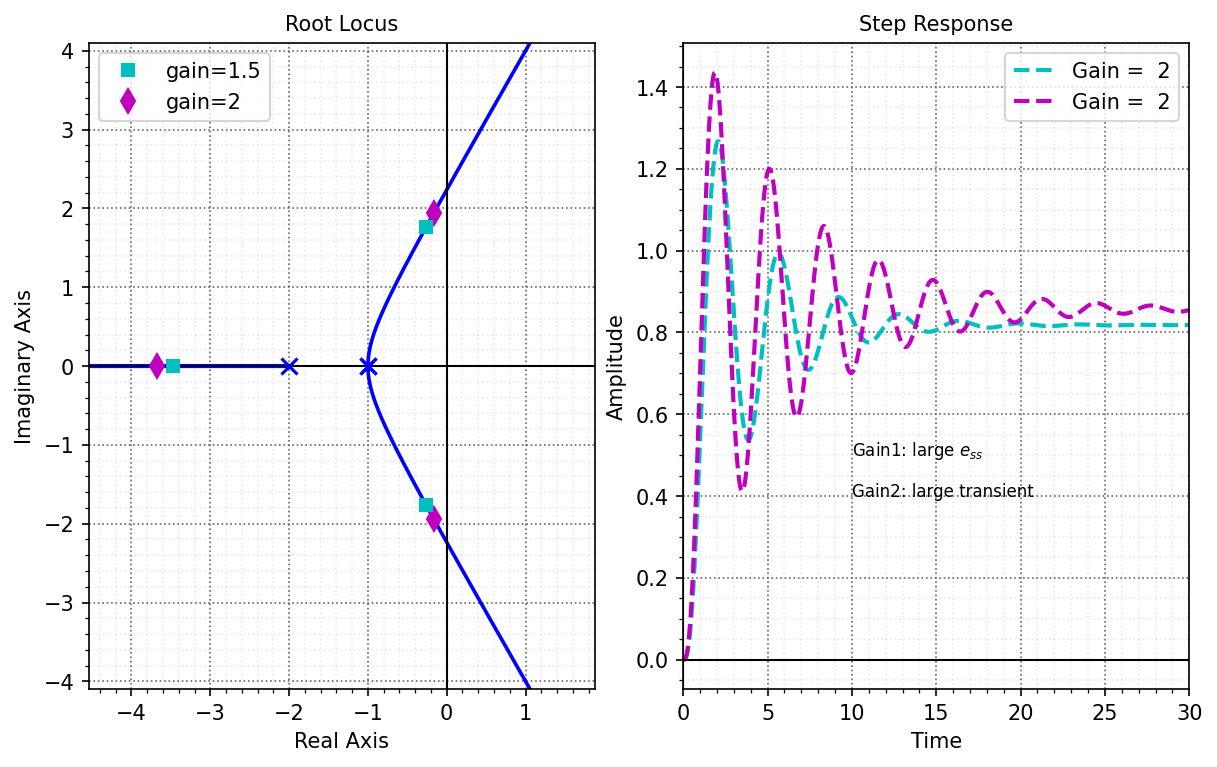

In [9]:
scale = 3
offset = np.sum(G.poles()).real/len(G.poles())
fig, ax = plt.subplots(1,2,figsize=(8, 5),dpi=150,constrained_layout = True,gridspec_kw={'width_ratios': [1, 1]})
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_aspect('equal')
ax[0].set_xlim([-4, 4]);ax[0].set_ylim([-4, 4])
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")
ax[0].set_title("Root Locus")
ax[0].plot(scl1.real,scl1.imag,'cs',ms=10,label=f"gain={gain1}")
ax[0].plot(scl2.real,scl2.imag,'md',ms=10,label=f"gain={gain2}")
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")
ax[0].set_title("Root Locus")
ax[0].axis('equal')
ax[0].set_xlim([-scale+offset,scale+offset])
ax[0].set_ylim([-scale,scale])
bm.nicegrid(ax[0])
unique = cm.color_rl(ax[0],verbose=True,ms=8)
if unique is not None:
    ax[0].legend(unique.values(), unique.keys())

ax[1].plot(t_lag1,y_lag1,'c--',label=r'Gain = {:2.0f}'.format(gain1))
ax[1].plot(t_lag2,y_lag2,'m--',label=r'Gain = {:2.0f}'.format(gain2))
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Amplitude")
ax[1].set_title("Step Response")
ax[1].text(10, 0.5, r"Gain1: large $e_{ss}$", fontsize=8, ha='left')
ax[1].text(10, 0.4, r"Gain2: large transient ", fontsize=8, ha='left')
ax[1].set_xlim([0,30])
bm.nicegrid(ax[1])
plt.legend()
plt.savefig('./figs/L17_5.pdf',dpi=600)
plt.show()


Found break-in/out at K = -0.000
At possible locations s = -1.000


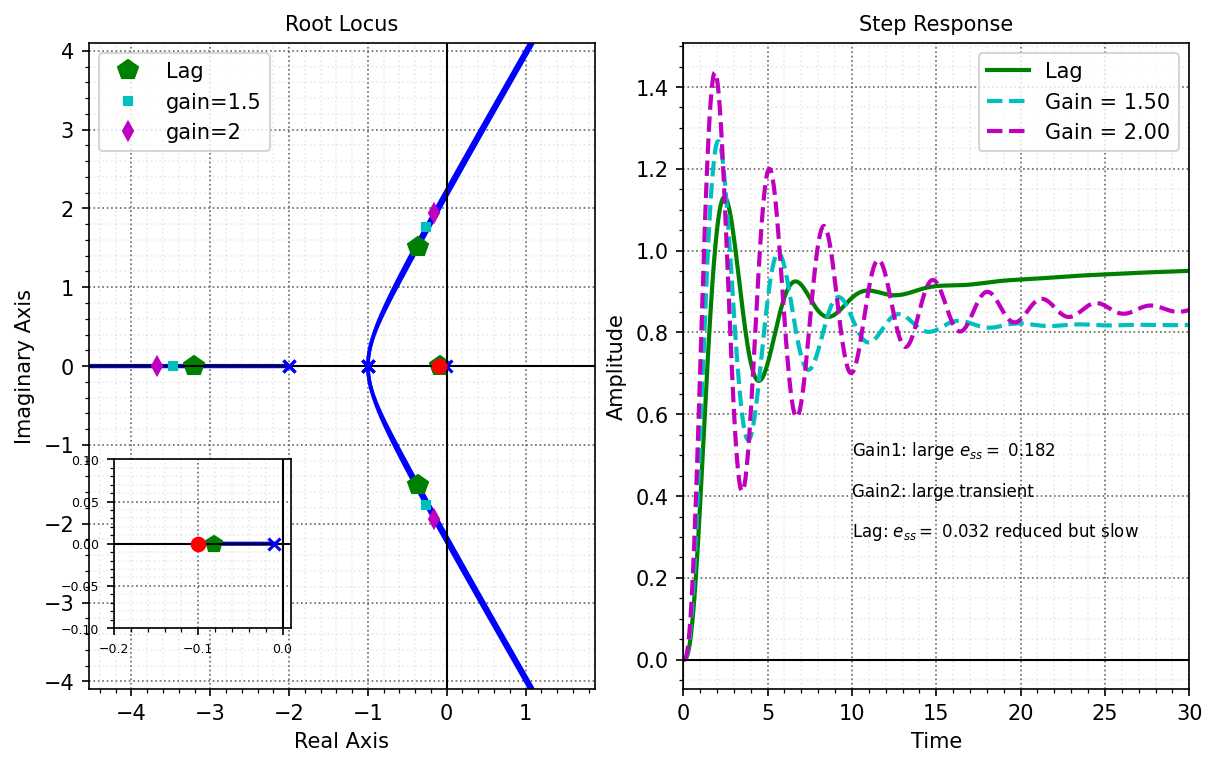

In [10]:
fig, ax = plt.subplots(1,2,figsize=(8, 5),dpi=150,constrained_layout = True,gridspec_kw={'width_ratios': [1, 1]})
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
rl = ct.rlocus(L, gains=cm.Root_Locus_gains(L), color='b', ax=ax[0])
ax[0].set_aspect('equal')
ax[0].set_xlim([-4, 4]);ax[0].set_ylim([-4, 4])
ax[0].plot(scl.real,scl.imag,'gp',ms=10,label=f"Lag")
ax[0].plot(scl1.real,scl1.imag,'cs',ms=10,label=f"gain={gain1}")
ax[0].plot(scl2.real,scl2.imag,'md',ms=10,label=f"gain={gain2}")
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")
ax[0].set_title("Root Locus")
ax[0].axis('equal')
ax[0].set_xlim([-scale+offset,scale+offset])
ax[0].set_ylim([-scale,scale])
bm.nicegrid(ax[0])
unique = cm.color_rl(ax[0],verbose=True)
if unique is not None:
    ax[0].legend(unique.values(), unique.keys())
ax_inset0 = ax[0].inset_axes([0.05, 0.05, 0.35, 0.35])  # bottom-left
rl = ct.rlocus(L, gains=cm.Root_Locus_gains(L), color='b', ax=ax_inset0)
ax_inset0.plot(scl.real, scl.imag, 'gp', ms=8)
ax_inset0.plot(scl1.real, scl1.imag, 'cs', ms=8)
ax_inset0.plot(scl2.real, scl2.imag, 'md', ms=8)
ax_inset0.set_xlim([-0.2, 0.01])
ax_inset0.set_ylim([-0.1, 0.1])
ax_inset0.set_aspect('equal')
bm.nicegrid(ax_inset0)
ax_inset0.tick_params(labelsize=6)
cm.color_rl(ax_inset0)

ax[1].plot(t_lag,y_lag,'g-',label='Lag')
ax[1].plot(t_lag1,y_lag1,'c--',label=r'Gain = {:.2f}'.format(gain1))
ax[1].plot(t_lag2,y_lag2,'m--',label=r'Gain = {:.2f}'.format(gain2))
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Amplitude")
ax[1].set_title("Step Response")
ax[1].text(10, 0.5, rf"Gain1: large $e_{{{{ss}}}} = $ {{:.3f}}".format(1-y_lag1[-1]), fontsize=8, ha='left')
ax[1].text(10, 0.4, r"Gain2: large transient ", fontsize=8, ha='left')
ax[1].text(10, 0.3, rf"Lag: $e_{{{{ss}}}} = $ {{:.3f}} reduced but slow".format(1-y_lag[-1]), fontsize=8, ha='left')
ax[1].set_xlim([0,30])
bm.nicegrid(ax[1])
plt.legend()
plt.savefig('./figs/L17_6.pdf',dpi=600)
plt.show()


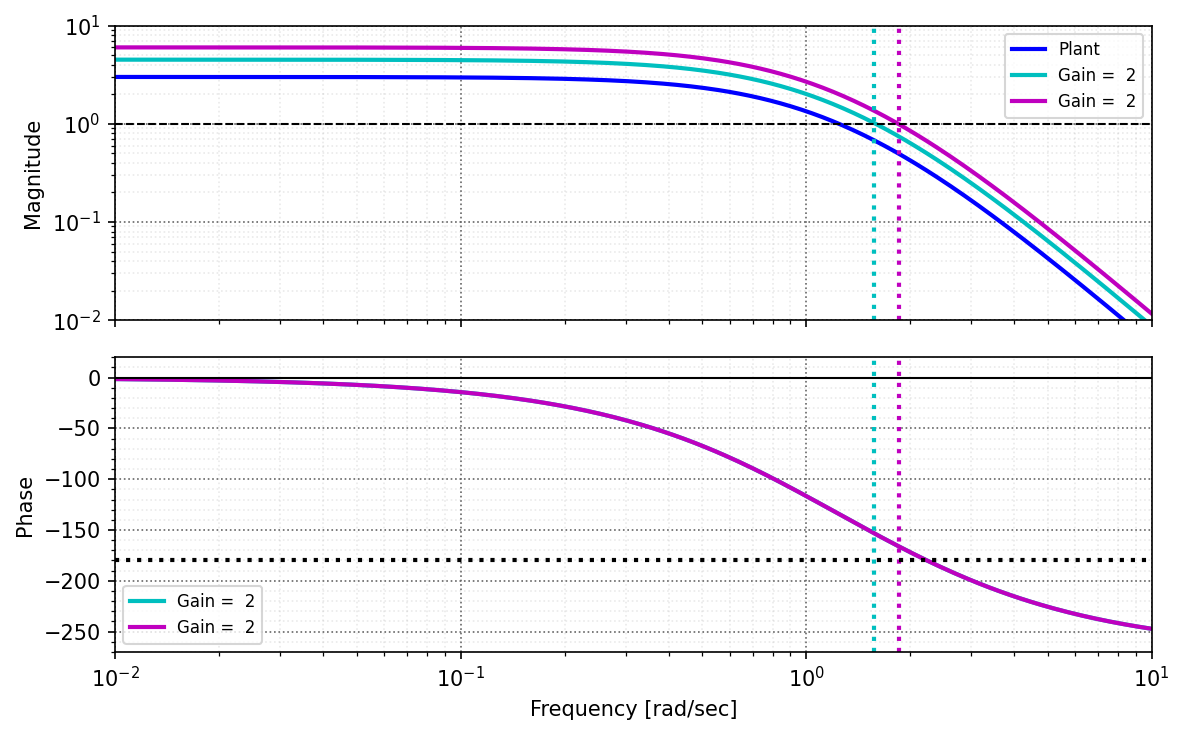

In [11]:
fig, ax = plt.subplots(2,1,figsize=(8,5),dpi=150,sharex=True)
ax[0].loglog(Gw,Gm,'b-',label='Plant')
ax[0].loglog(G1w,G1m,'c-',label=r'Gain = {:2.0f}'.format(gain1))
ax[0].loglog(G2w,G2m,'m-',label=r'Gain = {:2.0f}'.format(gain2))
ax[0].axvline(x=wc_gain1,c='c',ls=':')
ax[0].axvline(x=wc_gain2,c='m',ls=':')
ax[1].semilogx(G1w,np.unwrap(cm.pshift(G1p))*cm.r2d,'c-',label=r'Gain = {:2.0f}'.format(gain1))
ax[1].semilogx(G2w,np.unwrap(cm.pshift(G2p))*cm.r2d,'m-',label=r'Gain = {:2.0f}'.format(gain2))
ax[1].axvline(x=wc_gain1,c='c',ls=':')
ax[1].axvline(x=wc_gain2,c='m',ls=':')
ax[1].axhline(y=-180,c='k',ls=':')
ax[1].axhline(y=180,c='k',ls=':')

ax[0].legend(fontsize=8);ax[1].legend(fontsize=8)
ax[0].set_ylim([1e-2,10]);ax[1].set_ylim([-270,20])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L17_5a.pdf',dpi=600)
plt.show()

### <a id='toc1_2_1_'></a>[Add Lag](#toc0_)

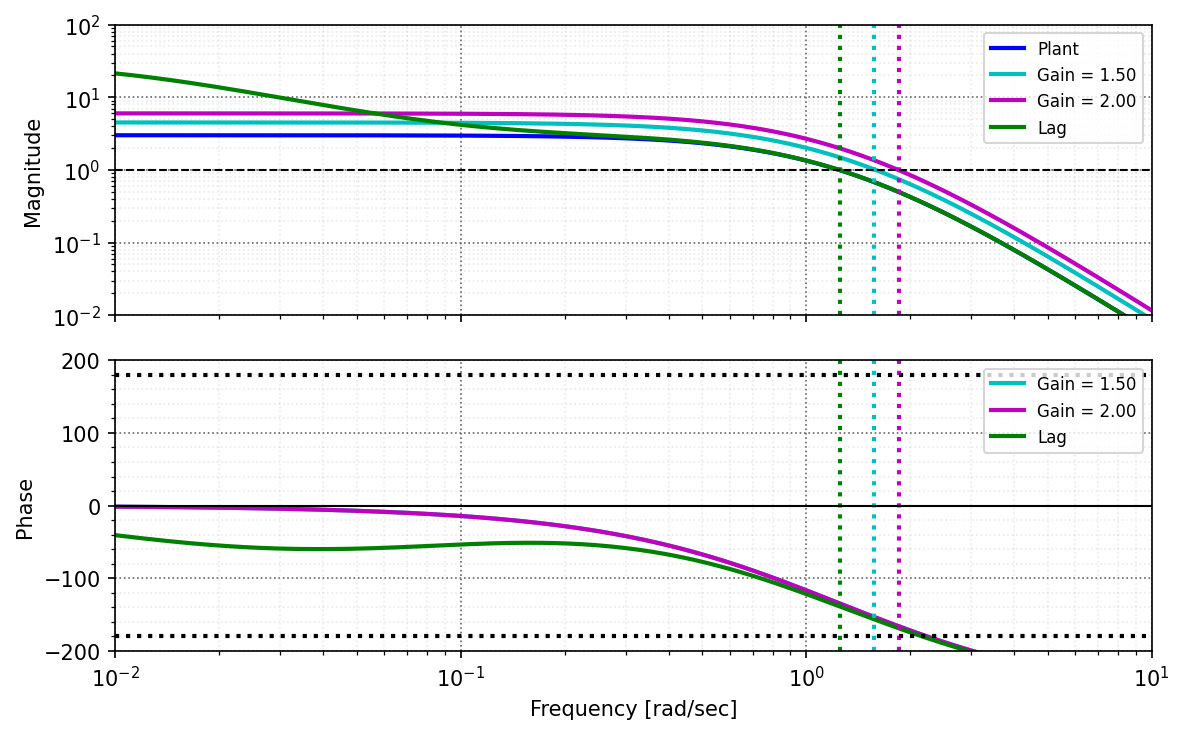

In [12]:
fig, ax = plt.subplots(2,1,figsize=(8,5),dpi=150,sharex=True)
ax[0].loglog(Gw,Gm,'b-',label='Plant')
ax[0].loglog(G1w,G1m,'c-',label=r'Gain = {:.2f}'.format(gain1))
ax[0].loglog(G2w,G2m,'m-',label=r'Gain = {:.2f}'.format(gain2))
ax[0].loglog(Lw,Lm,'g-',label='Lag')
ax[0].axvline(x=wc_gain1,c='c',ls=':')
ax[0].axvline(x=wc_gain2,c='m',ls=':')
ax[0].axvline(x=wc_lag,c='g',ls=':')
ax[1].semilogx(G1w,np.unwrap(cm.pshift(G1p))*cm.r2d,'c-',label=r'Gain = {:.2f}'.format(gain1))
ax[1].semilogx(G2w,np.unwrap(cm.pshift(G2p))*cm.r2d,'m-',label=r'Gain = {:.2f}'.format(gain2))
ax[1].semilogx(Lw,np.unwrap(cm.pshift(Lp))*cm.r2d,'g-',label='Lag')
ax[1].axvline(x=wc_gain1,c='c',ls=':')
ax[1].axvline(x=wc_gain2,c='m',ls=':')
ax[1].axhline(y=-180,c='k',ls=':')
ax[1].axhline(y=180,c='k',ls=':')
ax[1].axvline(x=wc_lag,c='g',ls=':')

ax[0].legend(fontsize=8);ax[1].legend(fontsize=8)
ax[0].set_ylim([1e-2,100]);ax[1].set_ylim([-200,200])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L17_6a.pdf',dpi=600)
plt.show()

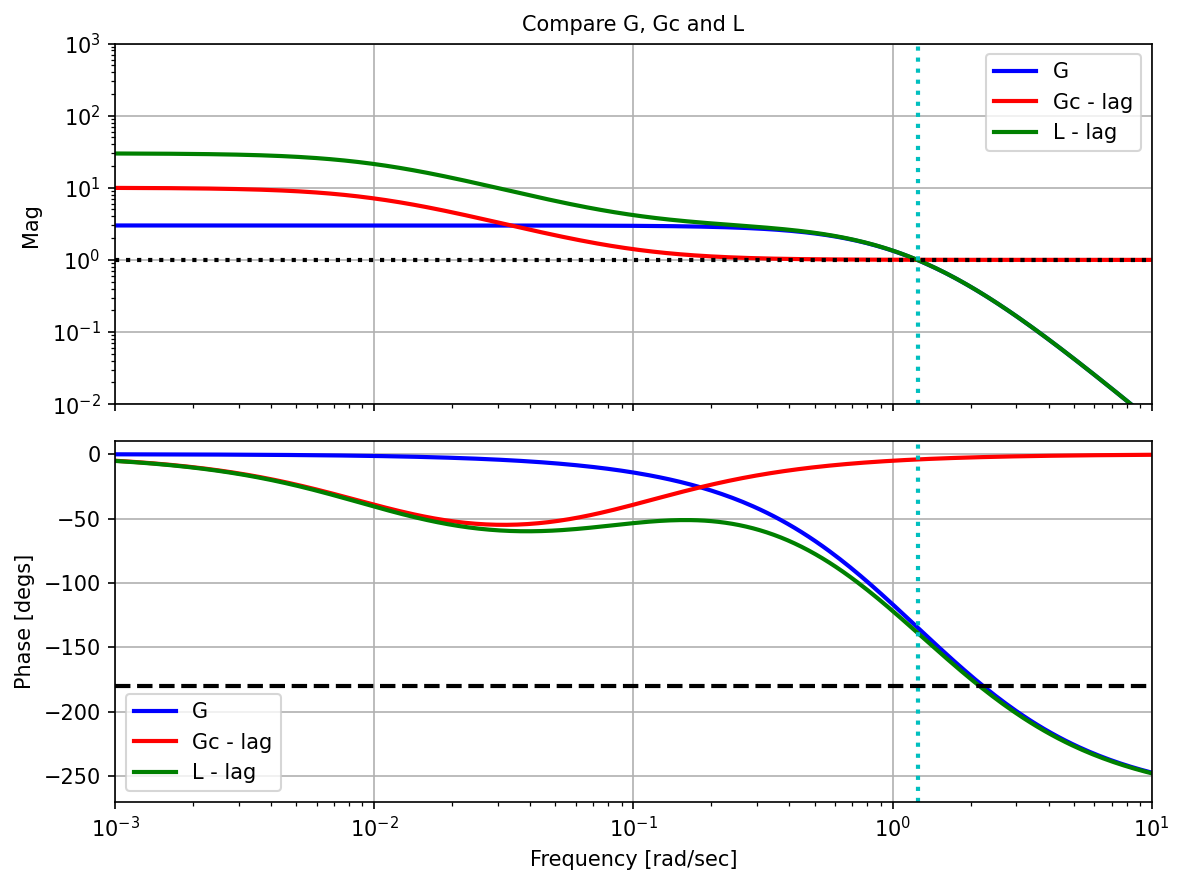

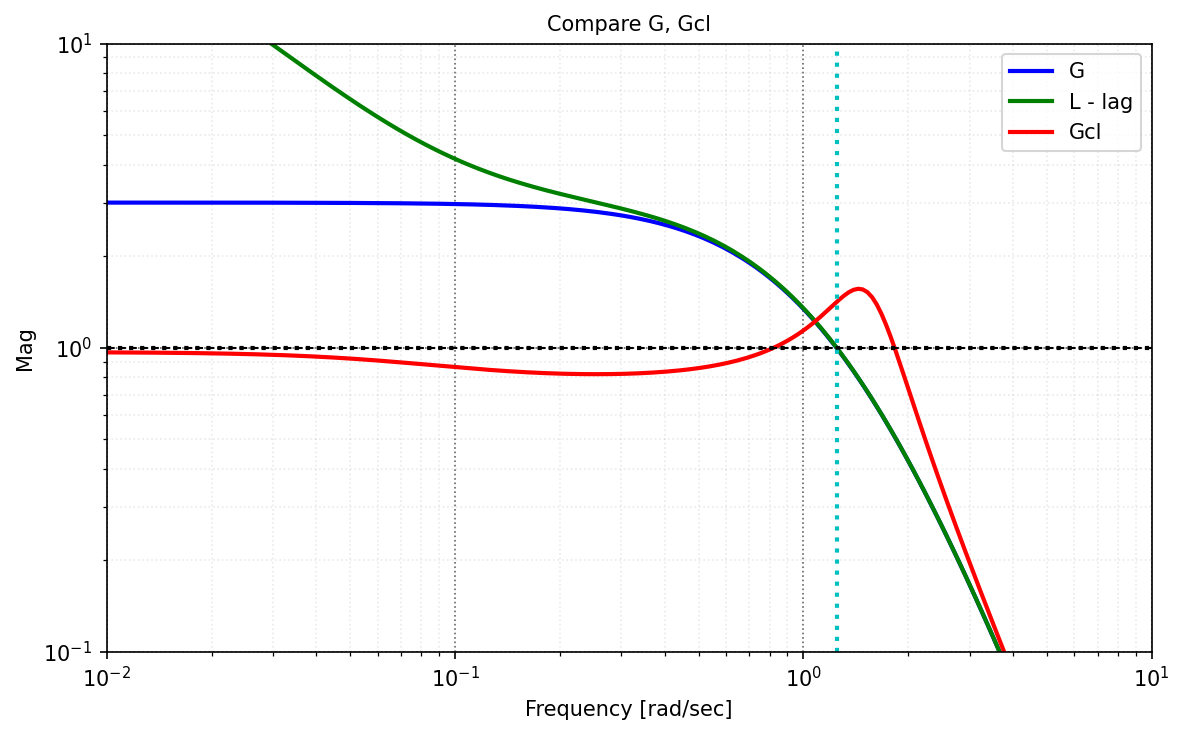

In [13]:
w = np.logspace(-3,np.log10(10),300)

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gclag,omega=w)
[Lm,Lp,Lw] = ct.frequency_response(L,omega=w)
[Gclm,Gclp,Gclw] = ct.frequency_response(Gcl,omega=w)

fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label='G')
ax[0].loglog(Gcw,Gcm,'r-',label='Gc - lag')
ax[0].loglog(Lw,Lm,'g-',label='L - lag')
ax[0].axhline(y=1,c='k',ls=":")
ax[0].axvline(x=wc_lag,c='c',ls=":")
ax[0].legend()
ax[0].set_ylim([.01,1000])
ax[0].set_ylabel("Mag ")

ax[1].semilogx(Gw,np.unwrap(cm.pshift(Gp))*cm.r2d,'b-',label='G')
ax[1].semilogx(Gcw,np.unwrap(cm.pshift(Gcp))*cm.r2d,'r-',label='Gc - lag')
ax[1].semilogx(Lw,np.unwrap(cm.pshift(Lp))*cm.r2d,'g-',label='L - lag')
ax[1].axvline(x=wc_lag,c='c',ls=":")
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylim([-270,10])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
ax[0].set_title("Compare G, Gc and L")
plt.legend()
plt.savefig('./figs/L17_6b.pdf',dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.loglog(Gw,Gm,'b-',label='G')
ax.loglog(Lw,Lm,'g-',label='L - lag')
ax.loglog(Gclw,Gclm,'r-',label='Gcl')
ax.axhline(y=1,c='k',ls=":")
ax.axvline(x=wc_lag,c='c',ls=":")
ax.legend()
ax.set_ylim([.1,10])
ax.set_xlim([.01,10])
ax.set_ylabel("Mag")
ax.set_xlabel("Frequency [rad/sec]")
ax.set_title("Compare G, Gcl")
plt.savefig('./figs/L17_6c.pdf',dpi=600)
bm.nicegrid(ax)
plt.show()

# <a id='toc2_'></a>[Bode design 3 (19-16)](#toc0_)

In [14]:
G = ct.tf(1,[1, 0]) * ct.tf(1,[1, 1])
wc_des = 1
PM = 45
Kv_des = 10 # current Kv is 1
w = np.sort(np.append(np.logspace(-3,np.log10(20),300),wc_des))

Gf = G(j*wc_des)
K_wc = 1/np.abs(Gf)
print(f"Gain at wc is {1/np.abs(Gf):.2f} to meet wc spec")

Kv_gain = cm.find_Kv(K_wc*G)
print(f"K_v = {Kv_gain:.2f} for G")

# so add lag
Gc_lag = cm.lag_design(gain_inc = Kv_des/(Kv_gain), gamma = 10, wc = wc_des)
display(cm.show_tf_latex(Gc_lag, "G_{c_{lag}}"))

L_lag = K_wc*G*Gc_lag
Lf = L_lag(j*wc_des)
Kv_L = cm.find_Kv(L_lag)
print(f"K_v = {Kv_L:.2f} for Lag")

Gcl_lag = ct.feedback(L_lag,1)

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gc_lag,omega=w)
[Lcm,Lcp,Lcw] = ct.frequency_response(L_lag,omega=w)

PM_gain = cm.find_PM(w,K_wc*G)
PM_lag = cm.find_PM(w,L_lag)
print("Loop with gain PM is {:4.2f}".format(PM_gain[0]))
print("Loop with Lag PM is {:4.2f}".format(PM_lag[0]))

Gain at wc is 1.41 to meet wc spec
K_v = 1.41 for G


<IPython.core.display.Math object>

None

K_v = 10.00 for Lag
Loop with gain PM is 45.00
Loop with Lag PM is 40.10


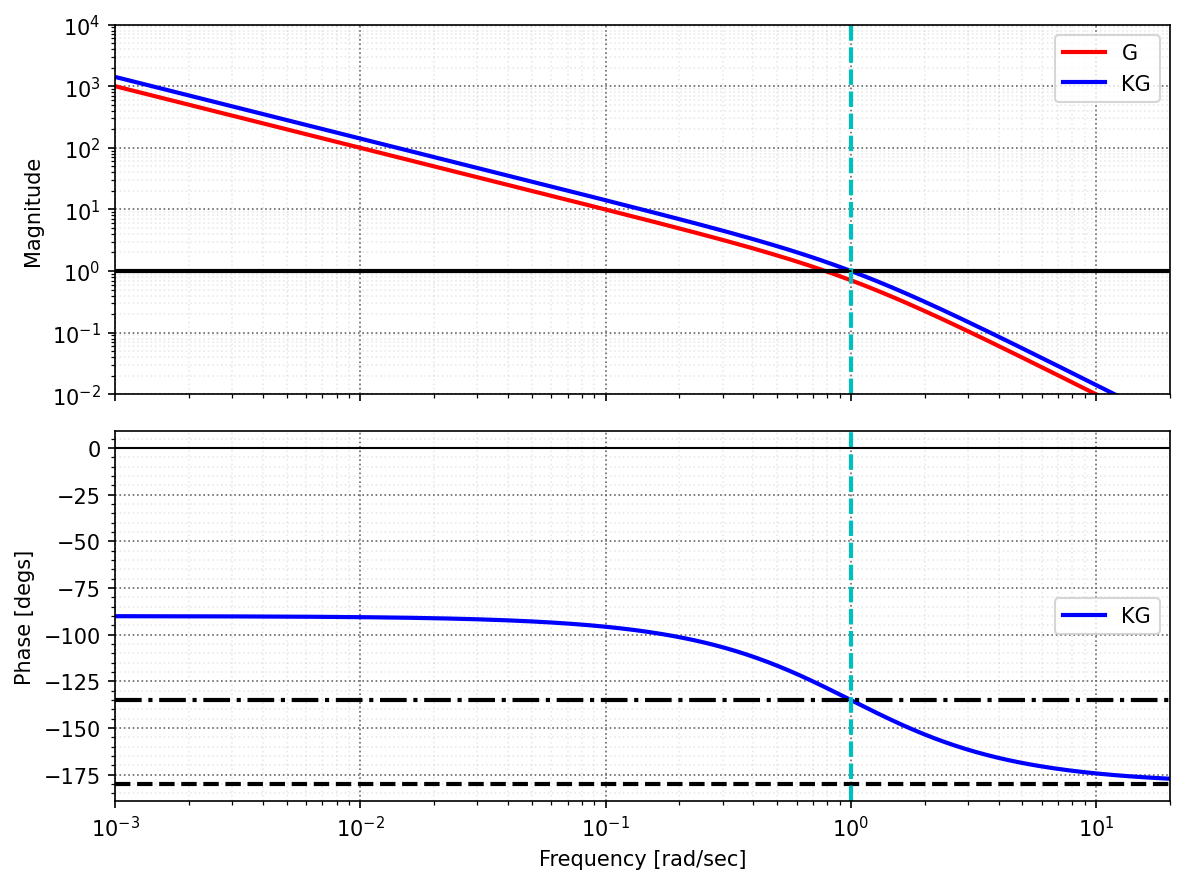

In [15]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'r-',label='G')
ax[0].loglog(Gw,K_wc*Gm,'b-',label='KG')
ax[0].axhline(y=1,c='k',ls="-")
ax[0].axvline(x=wc_des,c='c',ls="--")
ax[0].legend()
ax[0].set_ylim([.01,10000])
ax[0].set_ylabel("Magnitude")

ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'b-',label='KG')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axhline(y=-180+PM,c='k',ls="-.")
ax[1].axvline(x=wc_des,c='c',ls="--")
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
bm.nicegrid(ax)
plt.legend()
plt.savefig("./figs/L17_17p.pdf", dpi=600)
plt.show()

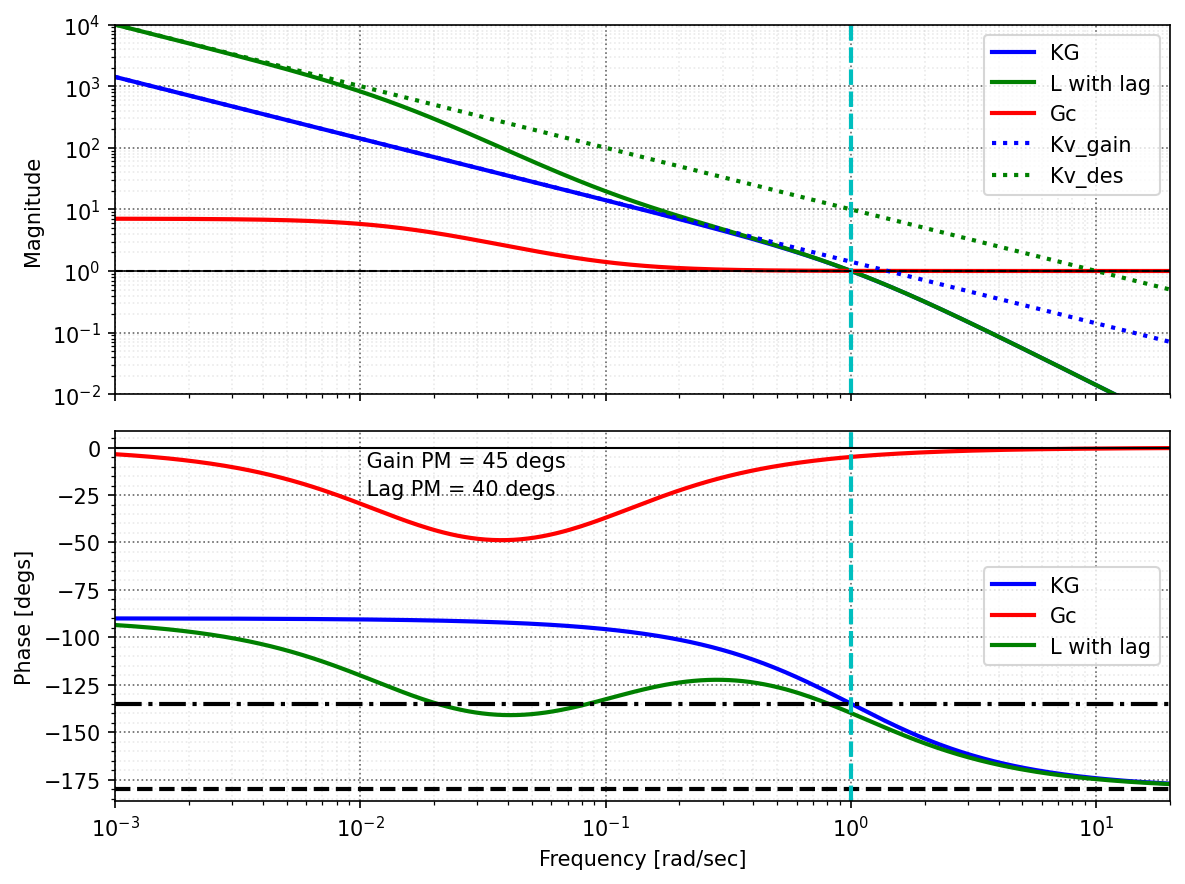

In [16]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,K_wc*Gm,'b-',label='KG')
ax[0].loglog(Lcw,Lcm,'g-',label='L with lag')
ax[0].loglog(Gcw,Gcm,'r-',label='Gc')
ax[0].loglog(Gcw,Kv_gain/Gcw,'b:',label='Kv_gain')
ax[0].loglog(Gcw,Kv_des/Gcw,'g:',label='Kv_des')
ax[0].axhline(y=1,c='k',ls="-",lw=0.75)
ax[0].axvline(x=wc_des,c='c',ls="--")
ax[0].legend()
ax[0].set_ylim([.01,10000])
ax[0].set_xlim([1e-3,1e2])
ax[0].set_ylabel("Magnitude")

ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'b-',label='KG')
ax[1].semilogx(Gcw,cm.pshift(Gcp)*cm.r2d,'r-',label='Gc')
ax[1].semilogx(Lcw,cm.pshift(Lcp)*cm.r2d,'g-',label='L with lag')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axhline(y=-180+PM,c='k',ls="-.")
ax[1].axvline(x=wc_des,c='c',ls="--")
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
ax[1].text(.01,-10,' Gain PM ={:3.0f} degs'.format(PM_gain[0]))
ax[1].text(.01,-25,' Lag PM ={:3.0f} degs'.format(PM_lag[0]))
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
bm.nicegrid(ax)
plt.legend()
plt.savefig("./figs/L17_17.pdf", dpi=600)
plt.show()

In [17]:
t = np.linspace(0,40,1000)
y_lag_ramp, t_lag_ramp, x_lag_ramp = cmat.lsim(ct.tf2ss(Gcl_lag), T=t, U=t)

L_lag = K_wc*G*Gc_lag
Gcl_K = ct.feedback(K_wc*G,1)
y_K_ramp, t_K_ramp, x_K_ramp = cmat.lsim(ct.tf2ss(Gcl_K), T=t, U=t)

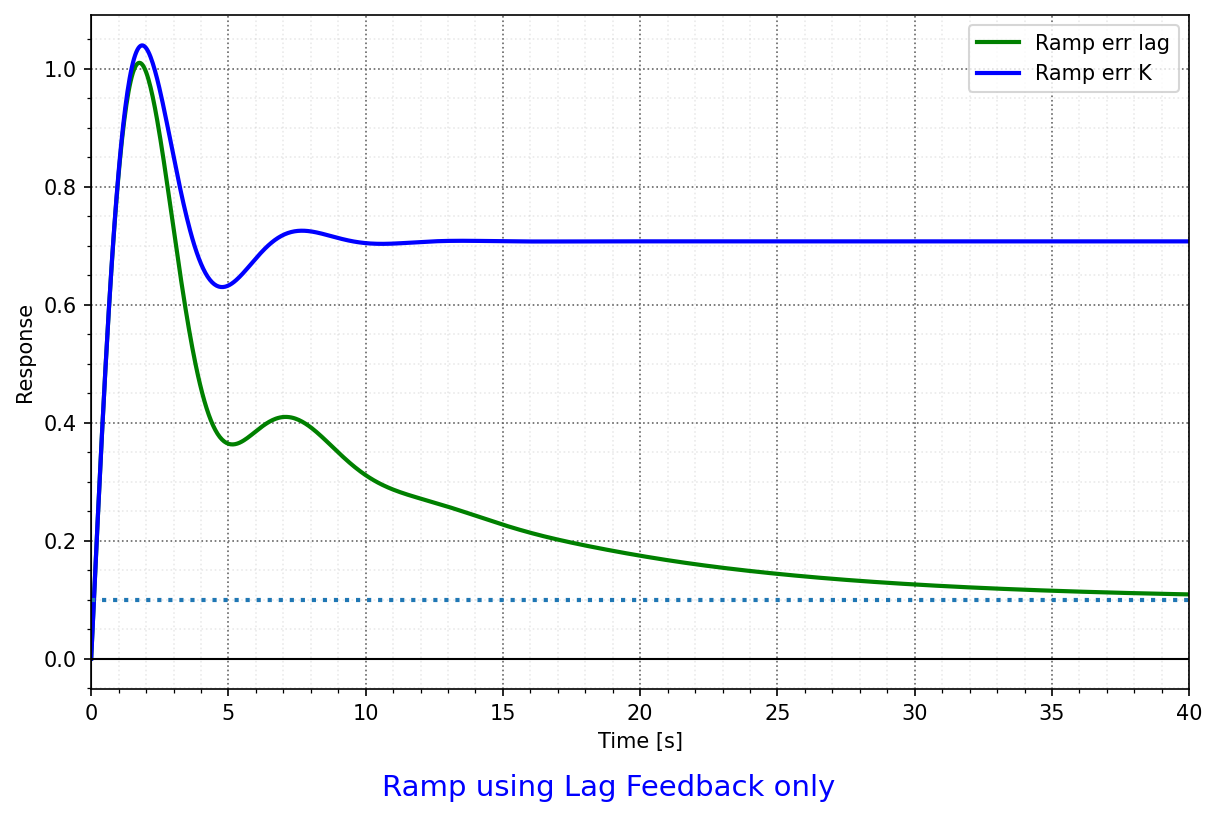

In [18]:
fig, ax = plt.subplots(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lag_ramp,(t_lag_ramp - y_lag_ramp),'g-',label='Ramp err lag')
plt.plot(t_K_ramp,(t_K_ramp - y_K_ramp),'b-',label='Ramp err K')
plt.axhline(y=1/Kv_des,ls=':')
bm.nicegrid(ax)
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
cm.caption("Ramp using Lag Feedback only",fig,yloc=-0.05)
plt.savefig("./figs/L17_17a.pdf", dpi=600)
plt.show()

# <a id='toc3_'></a>[Class example (19-19)](#toc0_)

In [21]:
s = ct.tf('s') 
G = 1/(s*(s+1)*(s+4))

Mp = 0.1325
zeta = 1/np.sqrt( 1 + (np.pi/np.log(Mp))**2 ) 
print(f"{zeta =: 4.2f}")
PM_des = zeta*100.
Kv_des = 12 # current Kv is much less

Tp = 1
wd = np.pi/Tp
wn = wd/np.sqrt(1-zeta**2)
wc_des = wn*np.sqrt(np.sqrt(1+4*zeta**4) - 2*zeta**2)
print(f"{wc_des =: 4.2f} rad/sec")


zeta = 0.54
wc_des = 2.83 rad/sec


In [41]:
# PM negative so add lead
Gc_lead = cm.lead_design(G, wc_des = wc_des, PMdes = PM_des)
L_K_lead = G*Gc_lead
Kv_lead = cm.find_Kv(L_K_lead)
print(f"{Kv_lead = :4.2f} with lead")
cm.show_tf_latex(Gc_lead, "G_{c_{lead}}(s)",show=True,factor=True,sigfigs=2)

Gc_lag = cm.lag_design(gain_inc = Kv_des/Kv_lead, gamma = 10, wc = wc_des)
cm.show_tf_latex(Gc_lag, "G_{c_{lag}}(s)",show=True)

L_lag = L_K_lead*Gc_lag
Kv_lag = cm.find_Kv(L_lag)

Gcl_K = ct.feedback(K_wc*G,1)
Gcl_lag = ct.feedback(L_lag,1)

print("Kv desired   = {:3.2f}".format(Kv_des))
print("Kv with lead = {:3.2f}".format(Kv_lead))
print("Kv with lag  = {:3.2f}".format(Kv_lag))

Gc_lag = cm.lag_design(gain_inc = Kv_des/Kv_lead, gamma = 10, wc = wc_des)

L = K_wc*G*Gc_lag*Gc_lead
Gcl = ct.feedback(L,1)
Lf = L(j*wc_des)
print("\nDesired PM is {:4.2f}".format(PM))
print("   Loop PM is {:4.2f}".format(180+cm.pshift(np.angle(Lf)*cm.r2d)))

w = np.sort(np.append(np.logspace(-3,np.log10(100),1000),wc_des))
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[L_leadm,L_leadp,L_leadw] = ct.frequency_response(L_K_lead,omega=w)
[L_lagm,L_lagp,L_lagw] = ct.frequency_response(L_lag,omega=w)


Kv_lead = 1.84 with lead


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Kv desired   = 12.00
Kv with lead = 1.84
Kv with lag  = 12.00

Desired PM is 45.00
   Loop PM is 49.27


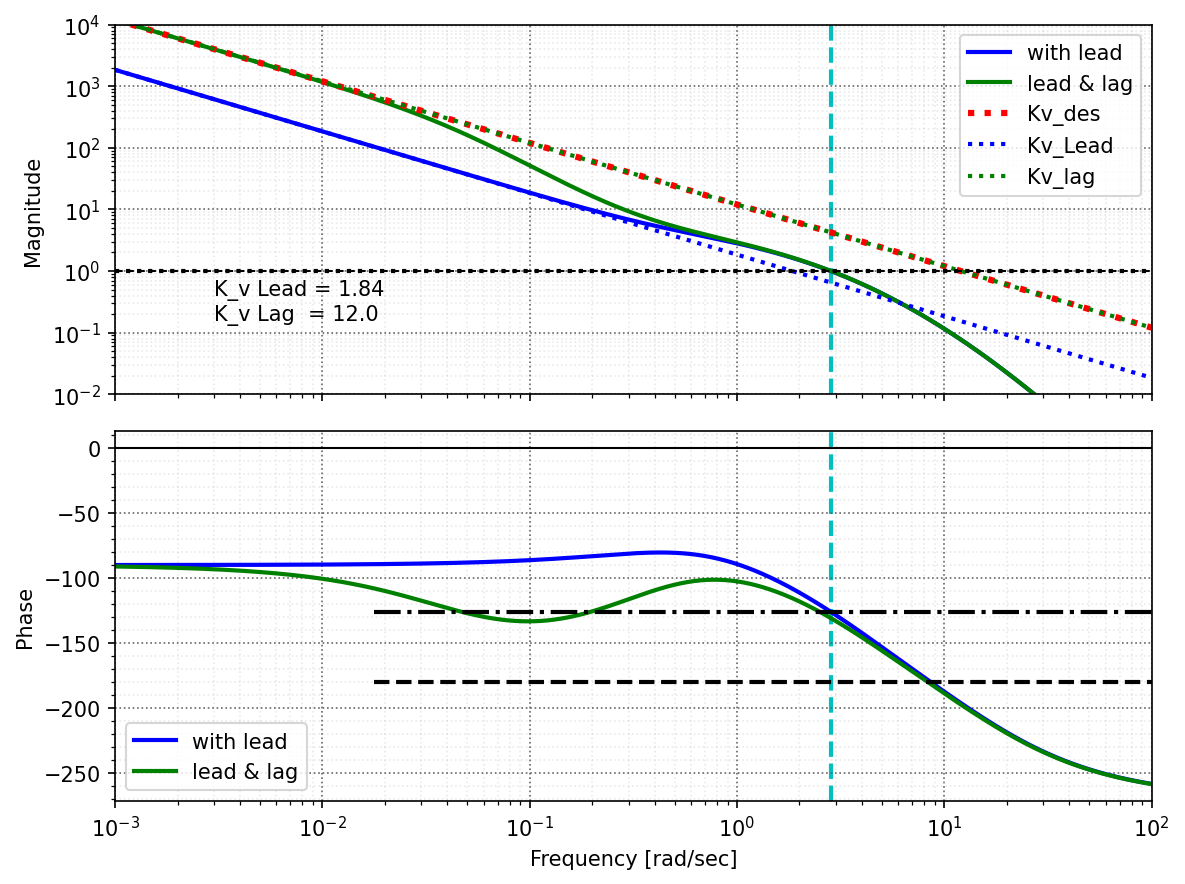

In [25]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(L_leadw,L_leadm,'b-',label='with lead')
ax[0].loglog(L_lagw,L_lagm,'g-',label='lead & lag')
ax[0].loglog(L_lagw,Kv_des/L_lagw,'r:',lw=3,label='Kv_des')
ax[0].loglog(L_lagw,Kv_lead/L_lagw,'b:',label='Kv_Lead')
ax[0].loglog(L_lagw,Kv_des/L_lagw,'g:',label='Kv_lag')
ax[0].axhline(y=1,c='k',ls=":")
ax[0].axvline(x=wc_des,c='c',ls="--",zorder=1)
ax[0].legend()
ax[0].set_ylim([.01,10000])
ax[0].set_ylabel("Magnitude")
ax[0].text(.003,0.5,'K_v Lead = {:.2f}'.format(Kv_lead),rotation=0,va='center',ha='left')
ax[0].text(.003,0.2,'K_v Lag  = {:.1f}'.format(Kv_lag),rotation=0,va='center',ha='left')

ax[1].semilogx(L_leadw,np.unwrap(L_leadp)*cm.r2d,'b-',label='with lead')
ax[1].semilogx(L_lagw,np.unwrap(L_lagp)*cm.r2d,'g-',label='lead & lag')
ax[1].axhline(y=-180,c='k',ls="--",xmin=0.25)
ax[1].axhline(y=-180+PM_des,c='k',ls="-.",xmin=0.25)
ax[1].axvline(x=wc_des,c='c',ls="--",zorder=1)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.legend()
plt.savefig("./figs/L17_18.pdf", dpi=600)
plt.show()


omega_n:	3.710
zeta   :	0.515
Tr     :	0.44s
Ts     :	2.35s
Mp     :	0.15
Tp     :	0.99s
Yss    :	1.03


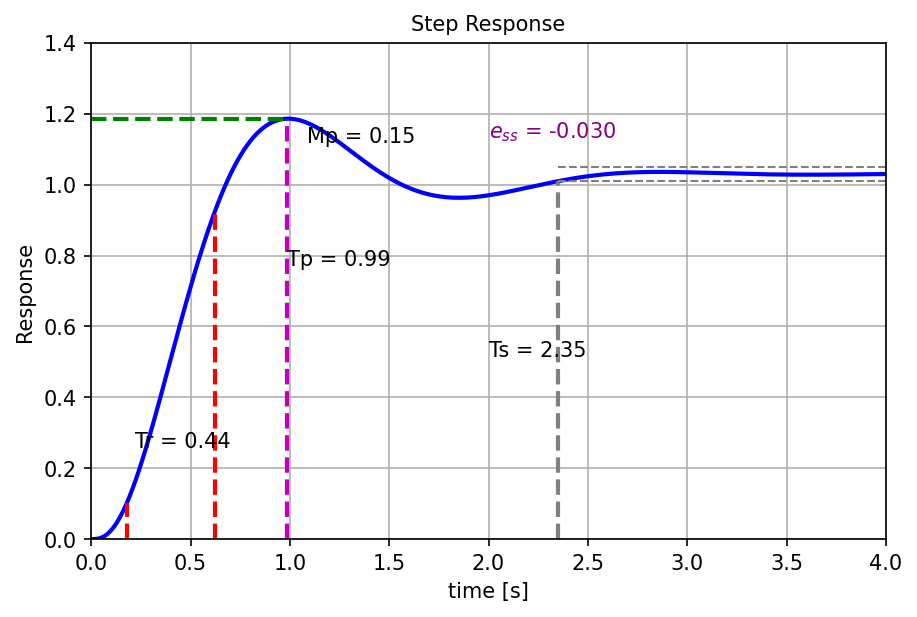

In [26]:
Gcl_gain = ct.feedback(K_wc*G,1)
Gcl_lead = ct.feedback(L_K_lead,1)
Gcl_lag = ct.feedback(L_lag,1)

y,t = cmat.step(ct.tf2ss(Gcl_lag),4)

fig, ax = plt.subplots(1,figsize=(6, 4),dpi=150,constrained_layout = True)
S = cm.Step_info(t,y)
S.printout()
S.nice_plot(ax,Ymax=1.4)
plt.savefig("./figs/L17_18a.pdf", dpi=600)
plt.show()

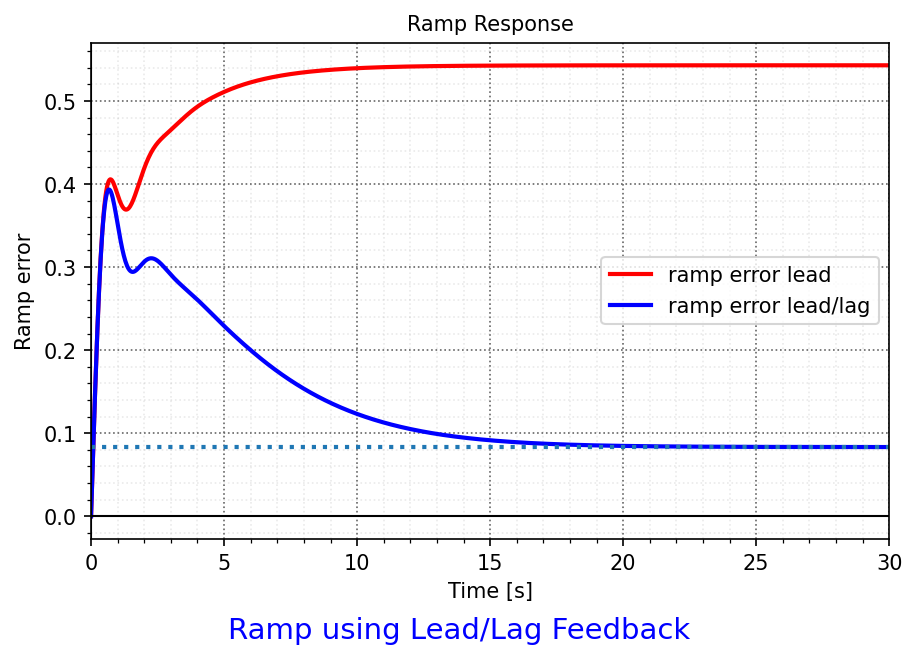

In [27]:
t = np.linspace(0,30,1000)
y_lead_ramp, t_lead_ramp, x_lead_ramp = cmat.lsim(ct.tf2ss(Gcl_lead), T=t, U=t)
y_lag_ramp, t_lag_ramp, x_lag_ramp = cmat.lsim(ct.tf2ss(Gcl_lag), T=t, U=t)

fig, ax = plt.subplots(figsize=(6, 4),dpi=150,constrained_layout = True)
plt.plot(t_lead_ramp,(t_lead_ramp - y_lead_ramp),'r-',label='ramp error lead')
plt.plot(t_lag_ramp,(t_lag_ramp - y_lag_ramp),'b-',label='ramp error lead/lag')
plt.axhline(y=1/Kv_des,ls=':')
bm.nicegrid(ax)
plt.xlabel("Time [s]")
plt.ylabel("Ramp error")
plt.title("Ramp Response")
plt.legend()
cm.caption("Ramp using Lead/Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L17_18b.pdf", dpi=600)
plt.show()

## PID version  

In [84]:
w= np.logspace(-2,2,1000)
G = 1/((s+1)**2*(s+4))
Gf = G(j*w)

Mp = 0.1325
zeta = 1/np.sqrt( 1 + (np.pi/np.log(Mp))**2 ) 
print(f"{zeta =: 4.2f}")
PM_des = zeta*100.
Kv_des = 12 # current Kv is much less

Tp = 1
wd = np.pi/Tp
wn = wd/np.sqrt(1-zeta**2)
wc_des = wn*np.sqrt(np.sqrt(1+4*zeta**4) - 2*zeta**2)
print(f"{wc_des =: 4.2f} rad/sec")

G_wc = G(j*wc_des)
Gp_wc = cm.wrap_phase_neg(np.angle(G_wc,deg=True))
Gm_wc = np.abs(G_wc)
print(rf"At wc = {wc_des:.2f} rad/sec, G has magnitude {Gm_wc:.2f} and phase {Gp_wc:.2f} deg")

zeta = 0.54
wc_des = 2.83 rad/sec
At wc = 2.83 rad/sec, G has magnitude 0.02 and phase -176.32 deg


In [85]:
phi_pid = PM_des - (180 + Gp_wc)
print(rf"PID design: need to add {phi_pid:.2f} deg of phase at wc = {wc_des:.2f} rad/sec")

PID design: need to add 50.43 deg of phase at wc = 2.83 rad/sec


In [86]:
cm.show_tf_latex(G, "G(s)",show=True,factor=True,sigfigs=2)

Kp = np.cos(np.radians(phi_pid))/Gm_wc
Kv_G = cm.find_Kv(G)
print(f"Current K_v is {Kv_G:.2f}, desired K_v is {Kv_des:.2f}")
Ki = Kv_des / G(1j*0).real
Kd = (Kp*np.tan(np.radians(phi_pid)) + Ki/wc_des)/wc_des
print(f"PID gains: Kp = {Kp:.2f}, Ki = {Ki:.2f}, Kd = {Kd:.2f}")
Gc_PID = Kp + Ki/s + Kd*s
cm.show_tf_latex(Gc_PID, "G_{c^{PID}}(s)",show=True,factor=True,sigfigs=2)
Gc_PIDf = Gc_PID(1j*w)

L_PID = G*Gc_PID
cm.show_tf_latex(L_PID, "L^{PID}(s)",show=True,factor=True,sigfigs=2)

L_PIDf = L_PID(1j*w)
Kv_PID = cm.find_Kv(L_PID)
print(f"PID K_v is {Kv_PID:.2f}")

<IPython.core.display.Math object>

Current K_v is 0.00, desired K_v is 12.00
PID gains: Kp = 28.09, Ki = 48.00, Kd = 18.02


<IPython.core.display.Math object>

<IPython.core.display.Math object>

PID K_v is 12.00


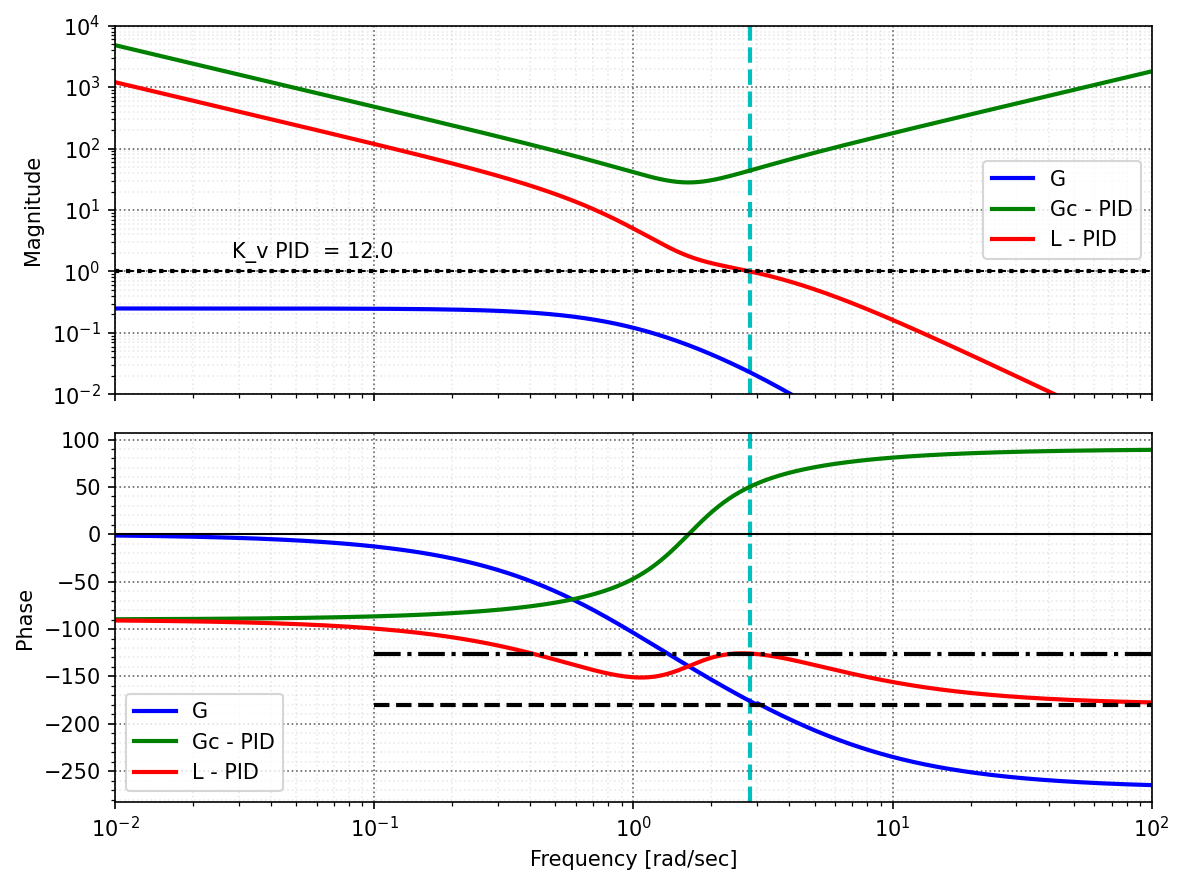

In [88]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(w,np.abs(Gf),'b-',label='G')
ax[0].loglog(w,np.abs(Gc_PIDf),'g-',label='Gc - PID')
ax[0].loglog(w,np.abs(L_PIDf),'r-',label='L - PID')
ax[0].axhline(y=1,c='k',ls=":")
ax[0].axvline(x=wc_des,c='c',ls="--",zorder=1)
ax[0].legend()
ax[0].set_ylim([.01,10000])
ax[0].set_ylabel("Magnitude")
ax[0].text(wc_des/100,2,'K_v PID  = {:.1f}'.format(Kv_PID),rotation=0,va='center',ha='left')

ax[1].semilogx(w,np.unwrap(np.angle(Gf,deg=True)),'b-',label='G')
ax[1].semilogx(w,np.unwrap(np.angle(Gc_PIDf,deg=True)),'g-',label='Gc - PID')
ax[1].semilogx(w,np.unwrap(np.angle(L_PIDf,deg=True)),'r-',label='L - PID')
ax[1].axhline(y=-180,c='k',ls="--",xmin=0.25)
ax[1].axhline(y=-180+PM_des,c='k',ls="-.",xmin=0.25)
ax[1].axvline(x=wc_des,c='c',ls="--",zorder=1)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.legend()
plt.savefig("./figs/L17_20a.pdf", dpi=600)
plt.show()

omega_n:	3.423
zeta   :	0.391
Tr     :	0.38s
Ts     :	5.82s
Mp     :	0.26
Tp     :	1.00s
Yss    :	1.00


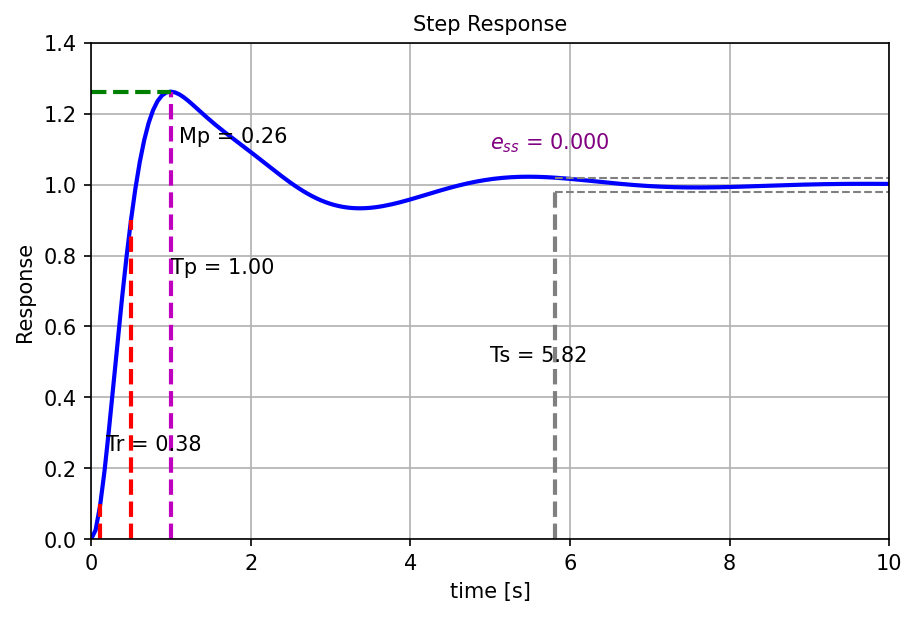

In [98]:
Gcl_PID = ct.feedback(L_PID,1)
y_PID,t_PID = cmat.step(ct.tf2ss(Gcl_PID),20)

fig, ax = plt.subplots(1,figsize=(6, 4),dpi=150,constrained_layout = True)
S = cm.Step_info(t_PID,y_PID)
S.printout()
S.nice_plot(ax,Ymax=1.4,Tmax=10)
plt.savefig("./figs/L17_20b.pdf", dpi=600)
plt.show()

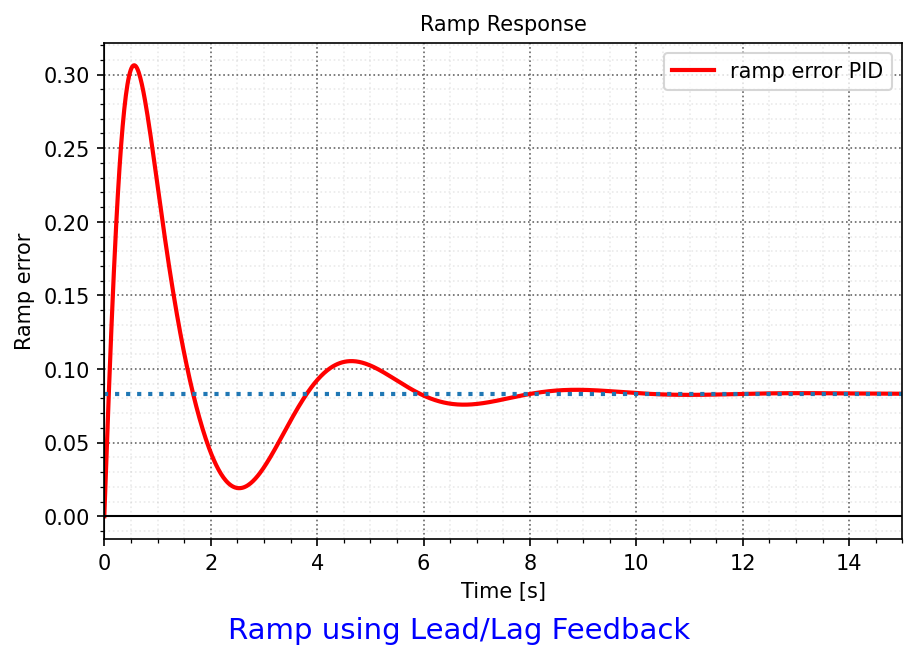

In [97]:
t = np.linspace(0,15,1000)
y_PID, t_PID, x_PID = cmat.lsim(ct.tf2ss(Gcl_PID), T=t, U=t)

fig, ax = plt.subplots(figsize=(6, 4),dpi=150,constrained_layout = True)
plt.plot(t_PID,(t_PID - y_PID),'r-',label='ramp error PID')
plt.axhline(y=1/Kv_des,ls=':')
bm.nicegrid(ax)
plt.xlabel("Time [s]")
plt.ylabel("Ramp error")
plt.title("Ramp Response")
plt.legend()
cm.caption("Ramp using Lead/Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L17_20c.pdf", dpi=600)
plt.show()